# 问题二：逐日滚动预测—CCP优化（代码版）

本 Notebook 按“数据审计 → 机理证据 → 1月选模 → 残差分布 → 2—12月滚动预测 → CCP规划与结算 → 事后比较”依次运行。复杂函数统一放在同目录 `q2_pipeline.py`，这里仅保留运行入口和必要说明。

**严格信息边界**

- 每天0:00一次性制定当天144个时段的计划，不使用当天真值日内更新；
- 模型选择只依据1月15—31日的前向滚动回测；
- 2—12月真值仅在每天结束后加入历史，供下一天更新，并用于事后评价与费用结算；
- 48小时规划联合考虑“今天＋明天”，但只执行今天；明天到来后重新预测、重新优化；
- 以2025年2月1日为正式规划起点。因缺少1月实际储能调度轨迹，假设该日0:00的SOC为6000 kWh；此后SOC逐日连续传递，不再重置。

## 1. 读取并审计数据

原始CSV中的时间为**时段结束时刻**，因此 `2025-02-01 00:00` 属于1月31日最后一个10分钟时段。`q2_pipeline.py` 通过“时间减10分钟”确定计划日。

In [1]:
from pathlib import Path
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from q2_pipeline import *

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
HERE = Path.cwd()
TRAIN_CSV = HERE / '附件2_训练集_2025年1月.csv'
FUTURE_CSV = HERE / '附件2_预测集_2025年2月起.csv'
PRICE_CSV = HERE / '附件1_分时电价.csv'

# 时间与模型参数
T, START = 144, 31                    # START=31 对应2025-02-01
ALPHA, LOOKBACK = 0.8, 14
ETA, RMAX = 0.9, 5000/6
SMIN, SMAX, S0 = 1200.0, 10800.0, 6000.0
ML_REFIT_EVERY = 1
GRU_INITIAL_EPOCHS, GRU_UPDATE_EPOCHS = 120, 5

dates, L, G = load_project_data(TRAIN_CSV, FUTURE_CSV)
price = pd.read_csv(PRICE_CSV, encoding='utf-8-sig')['电价'].to_numpy(float)

assert L.shape == G.shape == (365, 144)
assert len(price) == 144
assert not np.isnan(L).any() and not np.isnan(G).any()
assert dates[0] == pd.Timestamp('2025-01-01') and dates[-1] == pd.Timestamp('2025-12-31')

quality = pd.DataFrame({
    '项目': ['日期范围', '矩阵维度', '缺失值', '负值', '电价范围（元/kWh）'],
    '结果': [f'{dates[0].date()}—{dates[-1].date()}', str(L.shape),
           int(np.isnan(L).sum()+np.isnan(G).sum()), int((L<0).sum()+(G<0).sum()),
           f'{price.min():.4f}—{price.max():.4f}']
})
display(quality)
quality.to_csv(HERE/'数据质量摘要.csv', index=False, encoding='utf-8-sig')

,项目,结果
0,日期范围,2025-01-01—2025-12-31
1,矩阵维度,"(365, 144)"
2,缺失值,0
3,负值,0
4,电价范围（元/kWh）,0.3713—1.3952


## 2. 用1月数据核验预测结构

这里只提取与模型选择直接相关的证据：小区负荷按“周五、周六”和“周日至周四”分型；光伏不按星期分型，使用近期连续日。

In [2]:
jan_dates = dates[:31]
load_day = L[:31].sum(axis=1) / 6
pv_day = G[:31].sum(axis=1) / 6
low = jan_dates.dayofweek.isin([4, 5])

mechanism = pd.DataFrame({
    '证据': ['高负荷型日电量均值', '低负荷型日电量均值',
           '高负荷型组内CV', '低负荷型组内CV', '不分型负荷CV',
           '光伏日电量CV', '光伏星期均值最小值', '光伏星期均值最大值'],
    '结果': [load_day[~low].mean(), load_day[low].mean(),
           load_day[~low].std(ddof=1)/load_day[~low].mean(),
           load_day[low].std(ddof=1)/load_day[low].mean(),
           load_day.std(ddof=1)/load_day.mean(),
           pv_day.std(ddof=1)/pv_day.mean(),
           pd.Series(pv_day, index=jan_dates.dayofweek).groupby(level=0).mean().min(),
           pd.Series(pv_day, index=jan_dates.dayofweek).groupby(level=0).mean().max()],
    '单位': ['kWh', 'kWh', '比例', '比例', '比例', '比例', 'kWh', 'kWh']
})
display(mechanism.style.format({'结果':'{:,.4f}'}))

print('正式EW/EWMA：负荷取最近8个同类日指数加权；光伏取连续最近8日指数加权；衰减系数λ=0.6。')

,证据,结果,单位
0,高负荷型日电量均值,"126,638.0767",kWh
1,低负荷型日电量均值,"81,104.1971",kWh
2,高负荷型组内CV,0.0047,比例
3,低负荷型组内CV,0.0084,比例
4,不分型负荷CV,0.1853,比例
5,光伏日电量CV,0.0644,比例
6,光伏星期均值最小值,"37,126.4031",kWh
7,光伏星期均值最大值,"38,711.8087",kWh


正式EW/EWMA：负荷取最近8个同类日指数加权；光伏取连续最近8日指数加权；衰减系数λ=0.6。


## 3. 四种候选模型与1月前向滚动选模

- **EW/EWMA**：小区负荷使用最近8个同类型日；光伏使用连续最近8日，均取指数权重，$\lambda=0.6$；
- **岭回归**：采用原 `Q2 一月训练集 预测模型.ipynb` 实现——至多最近42天、`Ridge(alpha=1.0)`、标准化、滞后/差分/滚动统计、同类型日均值和1—3阶Fourier特征；
- **XGBoost**：逐日扩展训练，使用前1/2/7天滞后、差分、3/7天滚动统计以及Calendar特征；
- **GRU**：读取最近7个完整日的144点曲线，配合Calendar特征，直接输出次日144点曲线。

四个指标均针对净负荷电量误差；以 $\tau=0.8$ 的**平均日Pinball损失**为主选模指标。

In [3]:
t0 = time.time()
FC_JAN = make_all_forecasts(
    L, G, dates, start=14, end=31,
    ml_refit_every=ML_REFIT_EVERY,
    gru_initial_epochs=GRU_INITIAL_EPOCHS,
    gru_update_epochs=GRU_UPDATE_EPOCHS
)
JAN_METRICS = january_model_table(FC_JAN, L, G, start=14, end=31)
SELECTED_MODEL = JAN_METRICS.index[0]

display(JAN_METRICS.style.format('{:,.2f}'))
print(f'仅依据1月平均日Pinball损失选中：{SELECTED_MODEL}')
print(f'1月回测耗时：{time.time()-t0:.1f}秒')
JAN_METRICS.to_csv(HERE/'一月模型评价.csv', encoding='utf-8-sig')

,逐时段RMSE,平均日电量绝对误差,平均日Pinball损失,平均最大累计缺口,最大累计缺口P95
模型,,,,,
EW/EWMA,43.34,"1,846.11",653.27,744.35,"2,379.32"
岭回归,42.66,"1,757.59",674.81,852.50,"2,623.13"
XGBoost,50.19,"2,541.76","1,203.88","1,407.05","4,342.82"
GRU,91.55,"7,899.34","3,078.82","2,555.97","12,832.25"


仅依据1月平均日Pinball损失选中：EW/EWMA
1月回测耗时：4.2秒


## 4. 检查1月残差分布并确定安全余量

下图把正式模型在1月15—31日的净负荷残差汇总，用于判断是否适合正态近似。真正进入CCP的安全余量并不是这个汇总分位数，而是每天0:00按**过去14天、同一时段**滚动计算经验0.8分位数。

,样本量,均值_kWh,标准差_kWh,偏度,超额峰度,KS_p值,JB_p值,经验Q0.8_kWh,正态近似Q0.8_kWh,正态近似相对高估_%
0,"2,448",-6.245,42.9,-0.4908,3.619,7.626e-14,1.416e-310,20.98,29.86,42.3


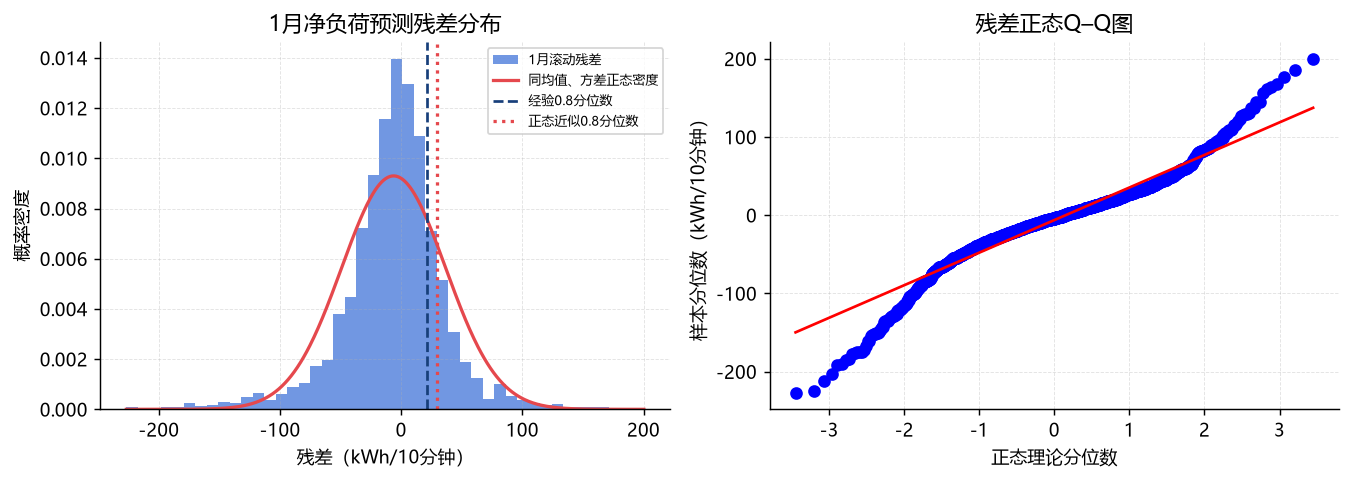

In [4]:
fl_jan = FC_JAN[SELECTED_MODEL]['load'][0]
fg_jan = FC_JAN[SELECTED_MODEL]['pv'][0]
eps_jan = ((L-G) - (fl_jan-fg_jan))[14:31].ravel() * DT
mu, sigma = eps_jan.mean(), eps_jan.std(ddof=1)
z = (eps_jan-mu)/sigma
ks = stats.kstest(z, 'norm')
jb = stats.jarque_bera(eps_jan)
q80_emp = np.quantile(eps_jan, ALPHA)
q80_norm = mu + stats.norm.ppf(ALPHA)*sigma

residual_test = pd.DataFrame({
    '样本量':[len(eps_jan)], '均值_kWh':[mu], '标准差_kWh':[sigma],
    '偏度':[stats.skew(eps_jan, bias=False)],
    '超额峰度':[stats.kurtosis(eps_jan, bias=False)],
    'KS_p值':[ks.pvalue], 'JB_p值':[jb.pvalue],
    '经验Q0.8_kWh':[q80_emp], '正态近似Q0.8_kWh':[q80_norm],
    '正态近似相对高估_%':[(q80_norm/q80_emp-1)*100]
})
display(residual_test.style.format('{:,.4g}'))

plt.rcParams.update({'font.sans-serif':['Microsoft YaHei','SimHei','DejaVu Sans'],
                     'axes.unicode_minus':False, 'figure.dpi':130,
                     'axes.spines.top':False, 'axes.spines.right':False})
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].hist(eps_jan, bins=45, density=True, color='#3A6FD8', alpha=.72, label='1月滚动残差')
x = np.linspace(eps_jan.min(), eps_jan.max(), 500)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), color='#E5484D', lw=1.8, label='同均值、方差正态密度')
axes[0].axvline(q80_emp, color='#173F7A', ls='--', lw=1.5, label='经验0.8分位数')
axes[0].axvline(q80_norm, color='#E5484D', ls=':', lw=1.8, label='正态近似0.8分位数')
axes[0].set(title='1月净负荷预测残差分布', xlabel='残差（kWh/10分钟）', ylabel='概率密度')
axes[0].legend(fontsize=7)
stats.probplot(eps_jan, dist='norm', plot=axes[1])
axes[1].set(title='残差正态Q–Q图', xlabel='正态理论分位数', ylabel='样本分位数（kWh/10分钟）')
for ax in axes: ax.grid(ls='--', lw=.5, alpha=.35)
plt.tight_layout()
plt.savefig(HERE/'一月EW_EWMA净负荷残差分布.png', dpi=220, bbox_inches='tight')
plt.show()

## 5. 生成2—12月逐日滚动预测

模型和参数在1月结束后冻结。此后第 $d$ 天0:00只使用第 $d-1$ 天及更早的真值；当天结束后再把第 $d$ 天的完整真值加入历史。为了给48小时规划提供明天曲线，EW/EWMA按明天的日期类型直接预测；岭回归、XGBoost和GRU采用各自模型的无泄漏递归次日预测。

In [5]:
t0 = time.time()
FC_ALL = make_all_forecasts(
    L, G, dates, start=14, end=len(dates),
    ml_refit_every=ML_REFIT_EVERY,
    gru_initial_epochs=GRU_INITIAL_EPOCHS,
    gru_update_epochs=GRU_UPDATE_EPOCHS
)
print(f'全年滚动预测完成：{time.time()-t0:.1f}秒')

全年滚动预测完成：75.0秒


## 6. 48小时CCP规划与真实结算

每个模型统一采用：

1. 过去14天同时段净负荷残差的经验0.8分位数作为安全余量；
2. 联合优化今天与明天共288个时段，但只执行今天144个时段；
3. 规划窗口内今明两天共用决策时点可得的同一组144维安全余量；
4. 日内计划冻结，实际缺口先由储能设备补足，剩余缺口按5倍电价紧急购电；
5. 以2025年2月1日为正式起点，因缺少1月实际调度轨迹，初始化 $S_{32,0}=6000$ kWh；以后 $S_{d+1,0}=S_{d,144}$。

第二天只是缓解日末短视的辅助时域，不提前执行；次日0:00会利用新增信息重新预测和优化。

In [6]:
t0 = time.time()
ccp_results = []
for model_name in ['EW/EWMA', '岭回归', 'XGBoost', 'GRU']:
    result = run_ccp(
        model_name, FC_ALL[model_name], L, G, price,
        start=START, alpha=ALPHA, lookback=LOOKBACK,
        eta=ETA, rmax=RMAX, smin=SMIN, smax=SMAX, s_init=S0
    )
    ccp_results.append(result)
    print(f'{model_name}: 完成')

COST = pd.DataFrame([
    {k:v for k,v in r.items() if k != '日明细'} for r in ccp_results
]).set_index('模型')
COST['相对最低总费用_%'] = (COST['总费用_万元']/COST['总费用_万元'].min()-1)*100
COST = COST.sort_values('总费用_万元')
assert COST['优化失败天数'].eq(0).all()
display(COST.style.format('{:,.2f}'))
print(f'2—12月共334天CCP规划与结算完成：{time.time()-t0:.1f}秒')
COST.to_csv(HERE/'2至12月_CCP费用对比.csv', encoding='utf-8-sig')

EW/EWMA: 完成


岭回归: 完成


XGBoost: 完成


GRU: 完成


,计划购电费_万元,紧急购电费_万元,其中惩罚增量_万元,总费用_万元,紧急购电量_kWh,惩罚天数,优化失败天数,相对最低总费用_%
模型,,,,,,,,
XGBoost,"1,316.11",43.24,34.59,"1,359.35","71,065.81",155.00,0.00,0.00
EW/EWMA,"1,316.41",47.02,37.62,"1,363.43","77,458.67",134.00,0.00,0.30
岭回归,"1,316.44",60.29,48.23,"1,376.74","98,776.27",141.00,0.00,1.28
GRU,"1,326.22",85.55,68.44,"1,411.77","136,138.08",147.00,0.00,3.86


2—12月共334天CCP规划与结算完成：17.2秒


## 7. 事后预测评价与汇总图

2—12月指标和费用仅用于固定方案后的样本外复盘，不反向改变1月选出的正式模型。

,逐时段RMSE,平均日电量绝对误差,平均日Pinball损失,平均最大累计缺口,最大累计缺口P95
模型,,,,,
XGBoost,59.75,"2,419.17","1,172.45","1,473.45","5,078.34"
EW/EWMA,59.85,"2,535.33","1,270.92","1,572.94","6,486.94"
岭回归,59.87,"2,819.01","1,489.14","1,831.33","6,574.17"
GRU,122.15,"8,825.36","2,321.32","1,183.11","8,150.05"


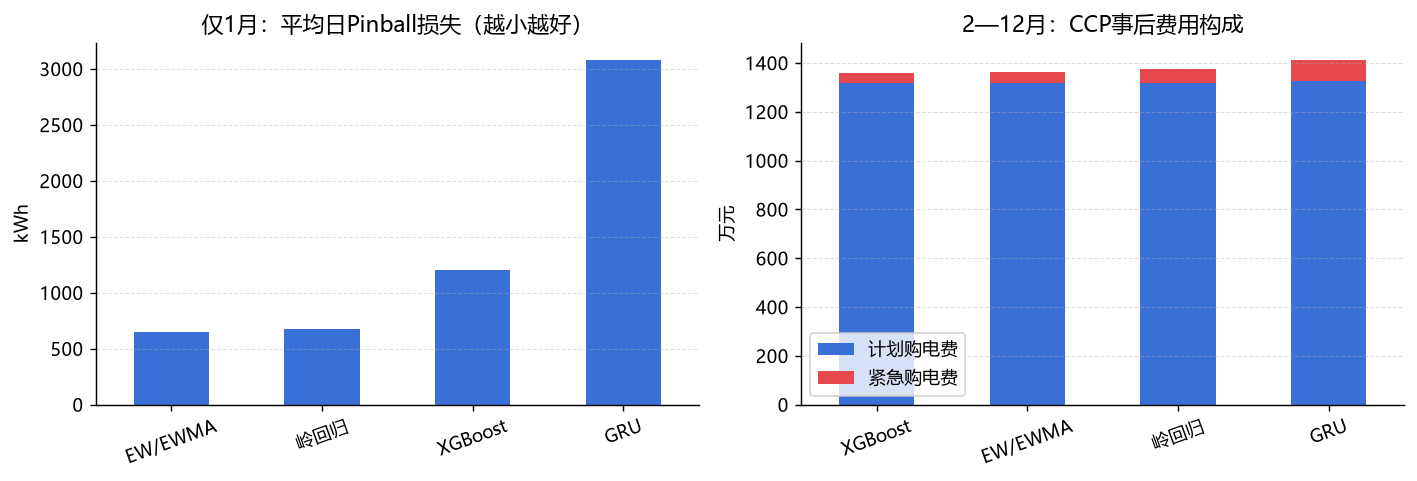

正式部署模型（仅按1月选定）：EW/EWMA
解释：后11个月的排序只反映数据积累后的事后表现，不构成反向选模依据。


In [7]:
OOS_METRICS = model_metrics_table(FC_ALL, L, G, start=START, end=len(dates))
display(OOS_METRICS.style.format('{:,.2f}'))
OOS_METRICS.to_csv(HERE/'2至12月_事后模型评价.csv', encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
JAN_METRICS['平均日Pinball损失'].sort_values().plot.bar(ax=axes[0], color='#3A6FD8')
axes[0].set_title('仅1月：平均日Pinball损失（越小越好）')
axes[0].set_ylabel('kWh'); axes[0].set_xlabel('')
plot_cost = COST[['计划购电费_万元','紧急购电费_万元']].rename(
    columns={'计划购电费_万元':'计划购电费', '紧急购电费_万元':'紧急购电费'}
)
plot_cost.plot.bar(stacked=True, ax=axes[1], color=['#3A6FD8','#E5484D'])
axes[1].set_title('2—12月：CCP事后费用构成')
axes[1].set_ylabel('万元'); axes[1].set_xlabel('')
for ax in axes:
    ax.grid(axis='y', ls='--', lw=.6, alpha=.4)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(HERE/'模型评价与费用对比.png', dpi=220, bbox_inches='tight')
plt.show()

print(f'正式部署模型（仅按1月选定）：{SELECTED_MODEL}')
print('解释：后11个月的排序只反映数据积累后的事后表现，不构成反向选模依据。')

## 8. 输出文件读取顺序

1. `一月模型评价.csv`：唯一选模证据；
2. `一月EW_EWMA净负荷残差分布.png`：经验分布余量的诊断依据；
3. `2至12月_事后模型评价.csv`：固定模型后的样本外预测复盘；
4. `2至12月_CCP费用对比.csv`：相同CCP与结算规则下的平行经济比较；
5. `模型评价与费用对比.png`：论文汇总图。

正式结论：EW/EWMA是在1月有限样本和真实信息边界下选出的部署模型；不能根据2—12月结果反向改选。